In [1]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots, ensemble_eval
from neuralhydrology.nh_run import start_run, eval_run

In [2]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name ='EXP02'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

## Grouping runs

In [3]:
## Sort to EXP02
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()

In [4]:
## Sort within EXP02
exp_count = eval_wrapper.check_exp_count(exp_runs)
exp_options = list(exp_count.keys())
exp_options.sort()
exp_options

EXP02_no_sw_transfer_9yrtr_2yrval :	 8
EXP02_wi_sw_transfer_9yrtr_1yrval :	 8
EXP02_no_sw_transfer_9yrtr_1yrval :	 8
EXP02_no_sw_transfer_10yrtr_1yrval :	 8
EXP02_wi_sw_transfer_2yrtr_1yrval :	 8
EXP02_wi_sw_transfer_10yrtr_1yrval :	 8
EXP02_wi_sw_transfer_1yrtr_2yrval :	 8
EXP02_wi_sw_transfer_9yrtr_2yrval :	 8
EXP02_no_sw_transfer_2yrtr_1yrval :	 8
EXP02_no_sw_transfer_1yrtr_2yrval :	 8


['EXP02_no_sw_transfer_10yrtr_1yrval',
 'EXP02_no_sw_transfer_1yrtr_2yrval',
 'EXP02_no_sw_transfer_2yrtr_1yrval',
 'EXP02_no_sw_transfer_9yrtr_1yrval',
 'EXP02_no_sw_transfer_9yrtr_2yrval',
 'EXP02_wi_sw_transfer_10yrtr_1yrval',
 'EXP02_wi_sw_transfer_1yrtr_2yrval',
 'EXP02_wi_sw_transfer_2yrtr_1yrval',
 'EXP02_wi_sw_transfer_9yrtr_1yrval',
 'EXP02_wi_sw_transfer_9yrtr_2yrval']

In [5]:
names_no_sw_10_1 = [run for run in all_runs if 'EXP02_no_sw_transfer_10yrtr_1yrval' in run]
names_wi_sw_10_1 = [run for run in all_runs if 'EXP02_wi_sw_transfer_10yrtr_1yrval' in run]

names_no_sw_9_1 = [run for run in all_runs if 'EXP02_no_sw_transfer_9yrtr_1yrval' in run]
names_wi_sw_9_1 = [run for run in all_runs if 'EXP02_wi_sw_transfer_9yrtr_1yrval' in run]

names_no_sw_9_2 = [run for run in all_runs if 'EXP02_no_sw_transfer_9yrtr_2yrval' in run]
names_wi_sw_9_2 = [run for run in all_runs if 'EXP02_wi_sw_transfer_9yrtr_2yrval' in run]

In [6]:
names_no_sw_2_1 = [run for run in all_runs if 'EXP02_no_sw_transfer_2yrtr_1yrval' in run]
names_wi_sw_2_1 = [run for run in all_runs if 'EXP02_wi_sw_transfer_2yrtr_1yrval' in run]

names_no_sw_1_2 = [run for run in all_runs if 'EXP02_no_sw_transfer_1yrtr_2yrval' in run]
names_wi_sw_1_2 = [run for run in all_runs if 'EXP02_wi_sw_transfer_1yrtr_2yrval' in run]

## Evaluate results

In [7]:
tuple_10_1 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_10_1,wisw_exp_names = names_wi_sw_10_1,run_dir=all_runs_dir)
tuple_9_1 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_9_1,wisw_exp_names = names_wi_sw_9_1,run_dir=all_runs_dir)
tuple_9_2 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_9_2,wisw_exp_names = names_wi_sw_9_2,run_dir=all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_10yrtr_1yrval_2808_140738
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_10yrtr_1yrval_2808_140738
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_10yrtr_1yrval_2808_140156
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_10yrtr_1yrval_2808_140156
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_t

In [8]:
tuple_2_1 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_2_1,wisw_exp_names = names_wi_sw_2_1,run_dir=all_runs_dir)
tuple_1_2 = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_no_sw_1_2,wisw_exp_names = names_wi_sw_1_2,run_dir=all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_2yrtr_1yrval_2808_134716
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_2yrtr_1yrval_2808_134716
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_2yrtr_1yrval_2808_133012
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_2yrtr_1yrval_2808_133012
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_trans

(-10.0, 1.0)

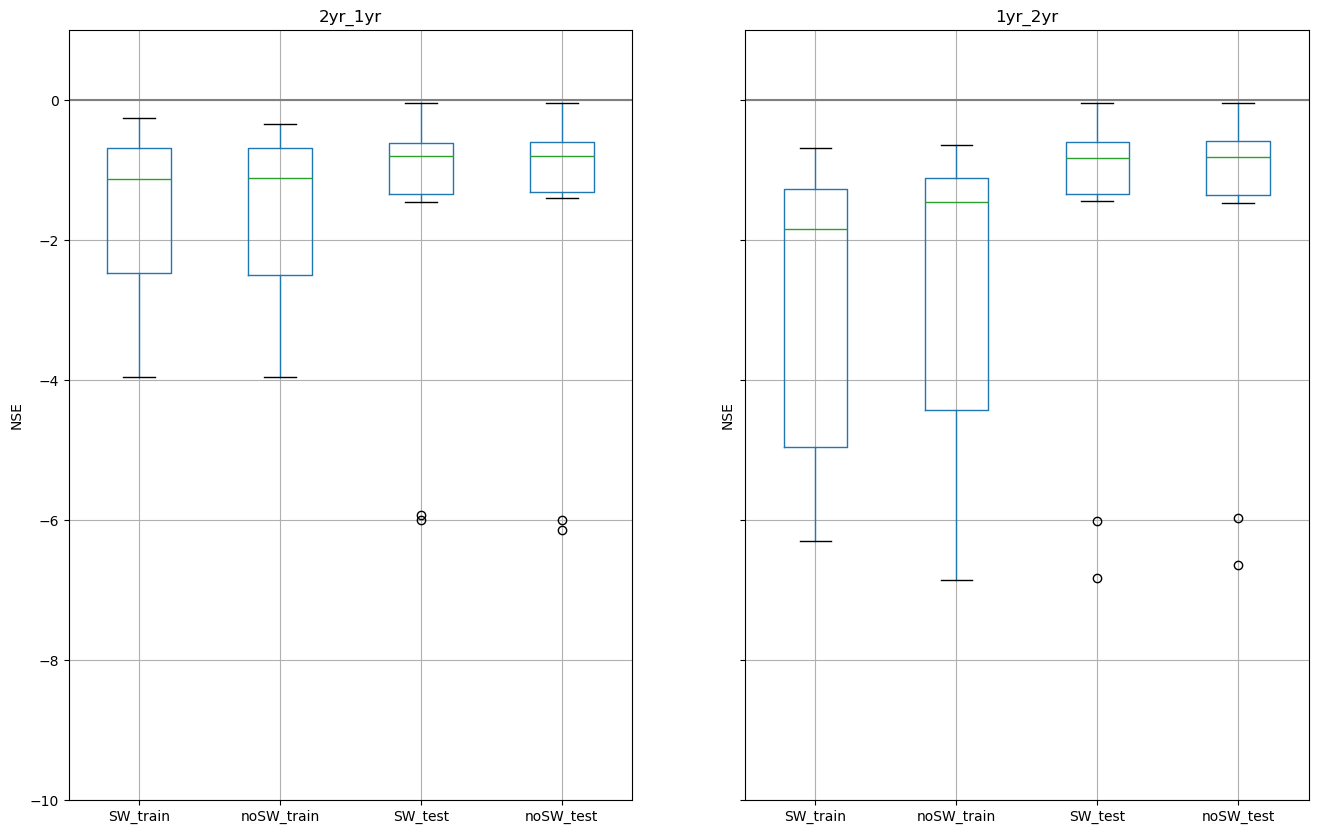

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10),sharey=True)
tr2_1_nse_df = comp_plots.boxplot_from_tuple(tuple_2_1,ax=axs[0],tuple_names=default_order,exp_name = '2yr_1yr')
tr1_2_nse_df = comp_plots.boxplot_from_tuple(tuple_1_2,ax=axs[1],tuple_names=default_order,exp_name = '1yr_2yr')
axs[0].set_ylim([-10,1])

(-1.0, 1.0)

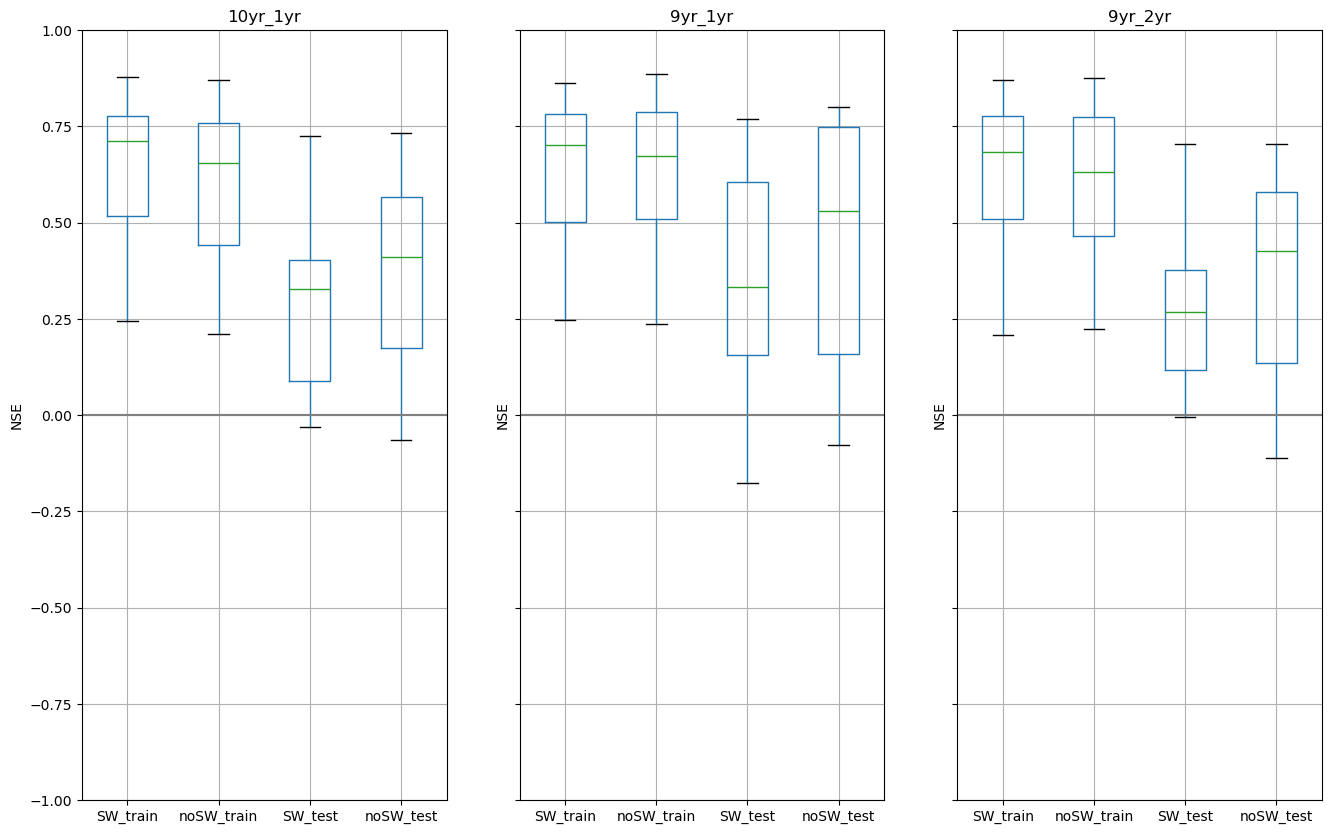

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(16, 10),sharey=True)
tr10_1_nse_df = comp_plots.boxplot_from_tuple(tuple_10_1,ax=axs[0],tuple_names=default_order,exp_name = '10yr_1yr')
tr9_1_nse_df = comp_plots.boxplot_from_tuple(tuple_9_1,ax=axs[1],tuple_names=default_order,exp_name = '9yr_1yr')
tr9_2_nse_df = comp_plots.boxplot_from_tuple(tuple_9_2,ax=axs[2],tuple_names=default_order,exp_name = '9yr_2yr')
axs[0].set_ylim([-1,1])